In [5]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from skimage.measure import label

test = True
shifts = [0]

index = 6

## Definitions

plot connected components

In [6]:
def plot_all_components(combined, figsize=(12, 10)):
    combined = torch.max(combined, dim=0).values
    N_components = combined.max()
    colors = plt.cm.rainbow(np.linspace(0, 1, N_components))
    np.random.shuffle(colors)
    colors = np.vstack([[0, 0, 0, 1], colors]) 
    cmap = mcolors.ListedColormap(colors)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    im = ax.imshow(combined.cpu(), cmap=cmap, interpolation='nearest')
    fig.colorbar(im, ticks=np.arange(1, N_components+1))

# Lines

C:\Users\levis\AppData\Local\Temp\ipykernel_6368\780739925.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  fig.colorbar(im, ticks=np.arange(1, N_components+1))


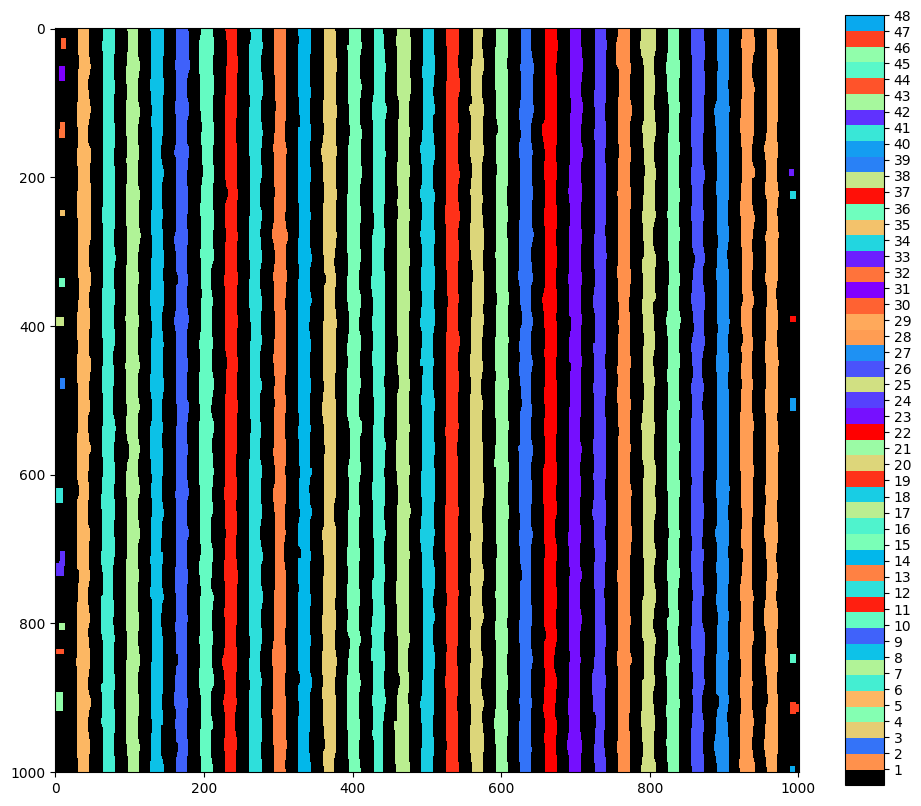

In [7]:
for shft in shifts:
    if not test:
        # synthetic data
        on_data_lines = ((torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/Files synthetic/components.pt") > 0.8) * 1.).to("cuda")
        No = on_data_lines.shape[1]

        input_array = on_data_lines[:,:No//2].cpu().numpy()

        labels = [label(i, connectivity=3) for i in input_array]
        labels = [np.concatenate([per_image, per_image], axis=0) for per_image in labels]

        plot_all_components(torch.tensor(labels[0]))

        num_labels = [l.max() for l in labels]

        masks = [torch.tensor((l == np.arange(1, num_labels[i] + 1)[:, None, None, None])*1) for i,l in enumerate(labels)]
        connected_components = masks

        # torch.save(connected_components, f"connected_components_{shft}.pt")

    else:
        on_data_lines = ((torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/Files experimental/lines_test_{index}.pt") > 0.8) * 1.).to("cuda")
        No = on_data_lines.shape[1]
        input_array = on_data_lines[:,:No//2].cpu().numpy()
        input_array.shape
        labels = [label(i, connectivity=3) for i in input_array]
        labels = [np.concatenate([per_image, per_image], axis=0) for per_image in labels]
        plot_all_components(torch.tensor(labels[0]))

        num_labels = [l.max() for l in labels]

        masks = [torch.tensor((l == np.arange(1, num_labels[i] + 1)[:, None, None, None])*1) for i,l in enumerate(labels)]
        connected_components = masks

        # torch.save(connected_components, f"connected_components_test_{index}.pt")

        

# Blobs

synthetic data

C:\Users\levis\AppData\Local\Temp\ipykernel_6368\780739925.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  fig.colorbar(im, ticks=np.arange(1, N_components+1))


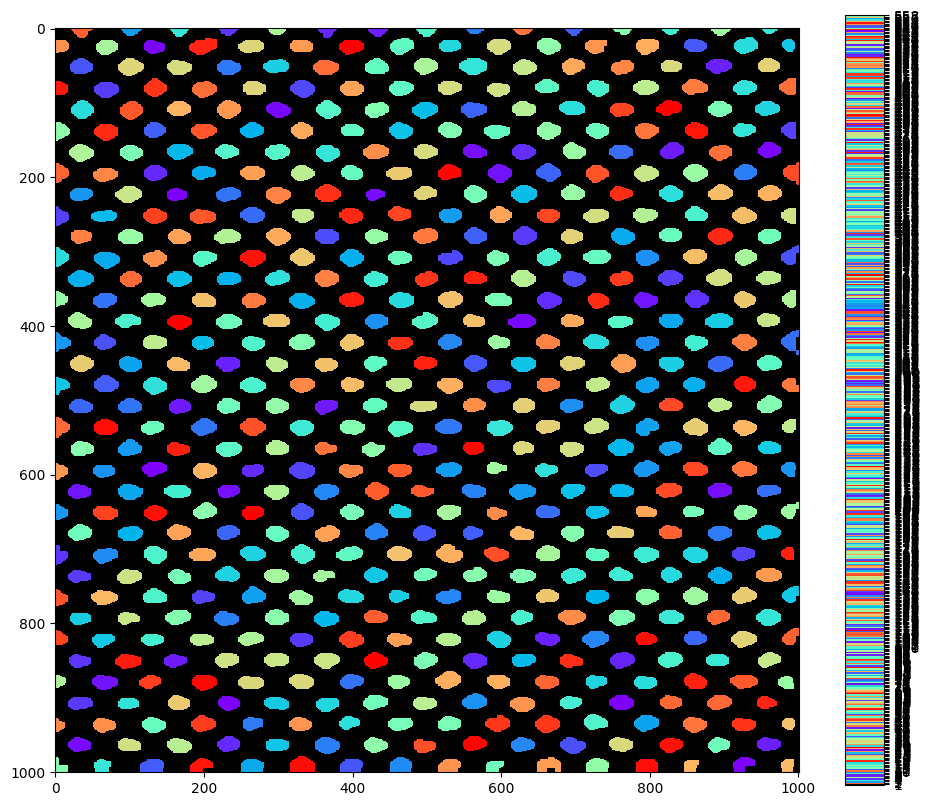

In [9]:
for shft in shifts:
    if not test:
        #synthetic data
        on_data_blobs = ((torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/Files synthetic/components_blobs.pt") > 0.8) * 1.).to("cuda") #shift_{shft}

        input_array = on_data_blobs.cpu().numpy()
        labels = [label(i, connectivity=2) for i in input_array]
        plot_all_components(torch.tensor(labels[0])[None])

        num_labels = [l.max() for l in labels]

        masks = [torch.tensor((l == np.arange(1, num_labels[i] + 1)[:, None, None])*1) for i,l in enumerate(labels)]
        connected_components_blobs = masks
        # torch.save(connected_components_blobs, f"connected_components_blobs.pt")

    else:
        #experimental data
        on_data_blobs = ((torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/Files experimental/blobs_test_{index}.pt") > 0.8) * 1.).to("cuda")
        input_array = on_data_blobs.cpu().numpy()
        input_array.shape
        labels = [label(i, connectivity=2) for i in input_array]
        plot_all_components(torch.tensor(labels[0])[None])

        num_labels = [l.max() for l in labels]

        masks = [torch.tensor((l == np.arange(1, num_labels[i] + 1)[:, None, None])*1) for i,l in enumerate(labels)]
        connected_components_blobs = masks
        # torch.save(connected_components_blobs, f"connected_components_blobs_test_{index}.pt")
